In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
# 1. Load MNIST (parser='auto' is recommended for newer sklearn)
print("Fetching MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target

Fetching MNIST... this might take a minute...


In [6]:
# 2. Filter for digits 0 and 1 only
binary_filter = np.where((y == '0') | (y == '1'))
X = X[binary_filter]
y = y[binary_filter].astype(int)

print(f"Dataset filtered! Shape: {X.shape} (Images of 0s and 1s)")

Dataset filtered! Shape: (14780, 784) (Images of 0s and 1s)


In [7]:
# 1. Standardize the data (Mean=0, Var=1) - Essential for PCA
X_scaled = StandardScaler().fit_transform(X)

# 2. Reduce dimensions from 784 pixels to 4 Principal Components
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# 3. Normalize to [0, 1] range
# We do this because Quantum Rotation Gates (Rx, Ry, Rz) typically take 
# inputs mapped to angles or values between 0 and 1.
X_quantum = MinMaxScaler(feature_range=(0, 1)).fit_transform(X_pca)

print(f"Data compressed! New feature shape: {X_quantum.shape}")

Data compressed! New feature shape: (14780, 4)


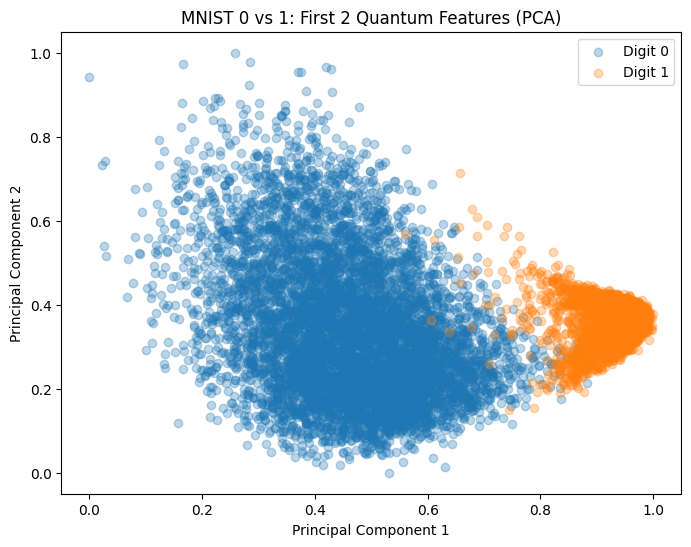

In [ ]:
plt.figure(figsize=(8, 6))
for i in [0, 1]:
    mask = (y == i) #mask is a boolen T or F depending on value of y
    plt.scatter(X_quantum[mask, 0], X_quantum[mask, 1], label=f'Digit {i}', alpha=0.3)

plt.title("MNIST 0 vs 1: First 2 Quantum Features (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [ ]:
import os

# Save the compressed Features (X) and Labels (y) into one file
np.savez('../data/mnist_01_quantum.npz', X=X_quantum, y=y)

print("Data saved successfully to data/mnist_01_quantum.npz!")no

Data saved successfully to data/mnist_01_quantum.npz!
